In [47]:
# Movie Rating Analysis and Visualization System

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# Load dataset
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\movies.csv")

print("=" * 60)
print("MOVIE RATING ANALYSIS AND VISUALIZATION SYSTEM")
print("=" * 60)

# Preview data
print("\nFirst 5 Records:\n")
print(df.head())

MOVIE RATING ANALYSIS AND VISUALIZATION SYSTEM

First 5 Records:

                 Movie_Name                      Genre  Year  Rating    Votes  \
0  The Shawshank Redemption                      Drama  1994     9.3  2500000   
1             The Godfather               Crime, Drama  1972     9.2  1800000   
2           The Dark Knight       Action, Crime, Drama  2008     9.0  2700000   
3              Pulp Fiction               Crime, Drama  1994     8.9  2100000   
4          Schindler's List  Biography, Drama, History  1993     8.9  1400000   

   Runtime  Revenue              Director  
0      142    28.34        Frank Darabont  
1      175   134.97  Francis Ford Coppola  
2      152   534.86     Christopher Nolan  
3      154   107.93     Quentin Tarantino  
4      195    96.90      Steven Spielberg  


In [48]:
# Dataset overview
print("\nDataset Overview:")
print("Total Movies:", len(df))
print("Average Rating:", round(df["Rating"].mean(), 2))
print("Highest Rating:", df["Rating"].max())
print("Lowest Rating:", df["Rating"].min())


Dataset Overview:
Total Movies: 35
Average Rating: 8.11
Highest Rating: 9.3
Lowest Rating: 2.8


In [49]:
# Top movies
top_rated = df.sort_values(by="Rating", ascending=False).head(5)
top_voted = df.sort_values(by="Votes", ascending=False).head(5)

# Genre analysis
genre_avg = df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)
genre_count = df["Genre"].value_counts()
print("\nTop 5 Rated Movies:\n")
print(top_rated[["Movie_Name", "Genre", "Rating", "Votes"]])

print("\nTop 5 Most Voted Movies:\n")
print(top_voted[["Movie_Name", "Genre", "Votes", "Rating"]])

print("\nGenre-wise Average Ratings:\n")
print(genre_avg)


Top 5 Rated Movies:

                                       Movie_Name                     Genre  \
0                        The Shawshank Redemption                     Drama   
1                                   The Godfather              Crime, Drama   
2                                 The Dark Knight      Action, Crime, Drama   
11  The Lord of the Rings: The Return of the King  Action, Adventure, Drama   
3                                    Pulp Fiction              Crime, Drama   

    Rating    Votes  
0      9.3  2500000  
1      9.2  1800000  
2      9.0  2700000  
11     9.0  1900000  
3      8.9  2100000  

Top 5 Most Voted Movies:

                 Movie_Name                      Genre    Votes  Rating
2           The Dark Knight       Action, Crime, Drama  2700000     9.0
0  The Shawshank Redemption                      Drama  2500000     9.3
5                 Inception  Action, Adventure, Sci-Fi  2400000     8.8
6                Fight Club                      Drama  

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1108\4284670033.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


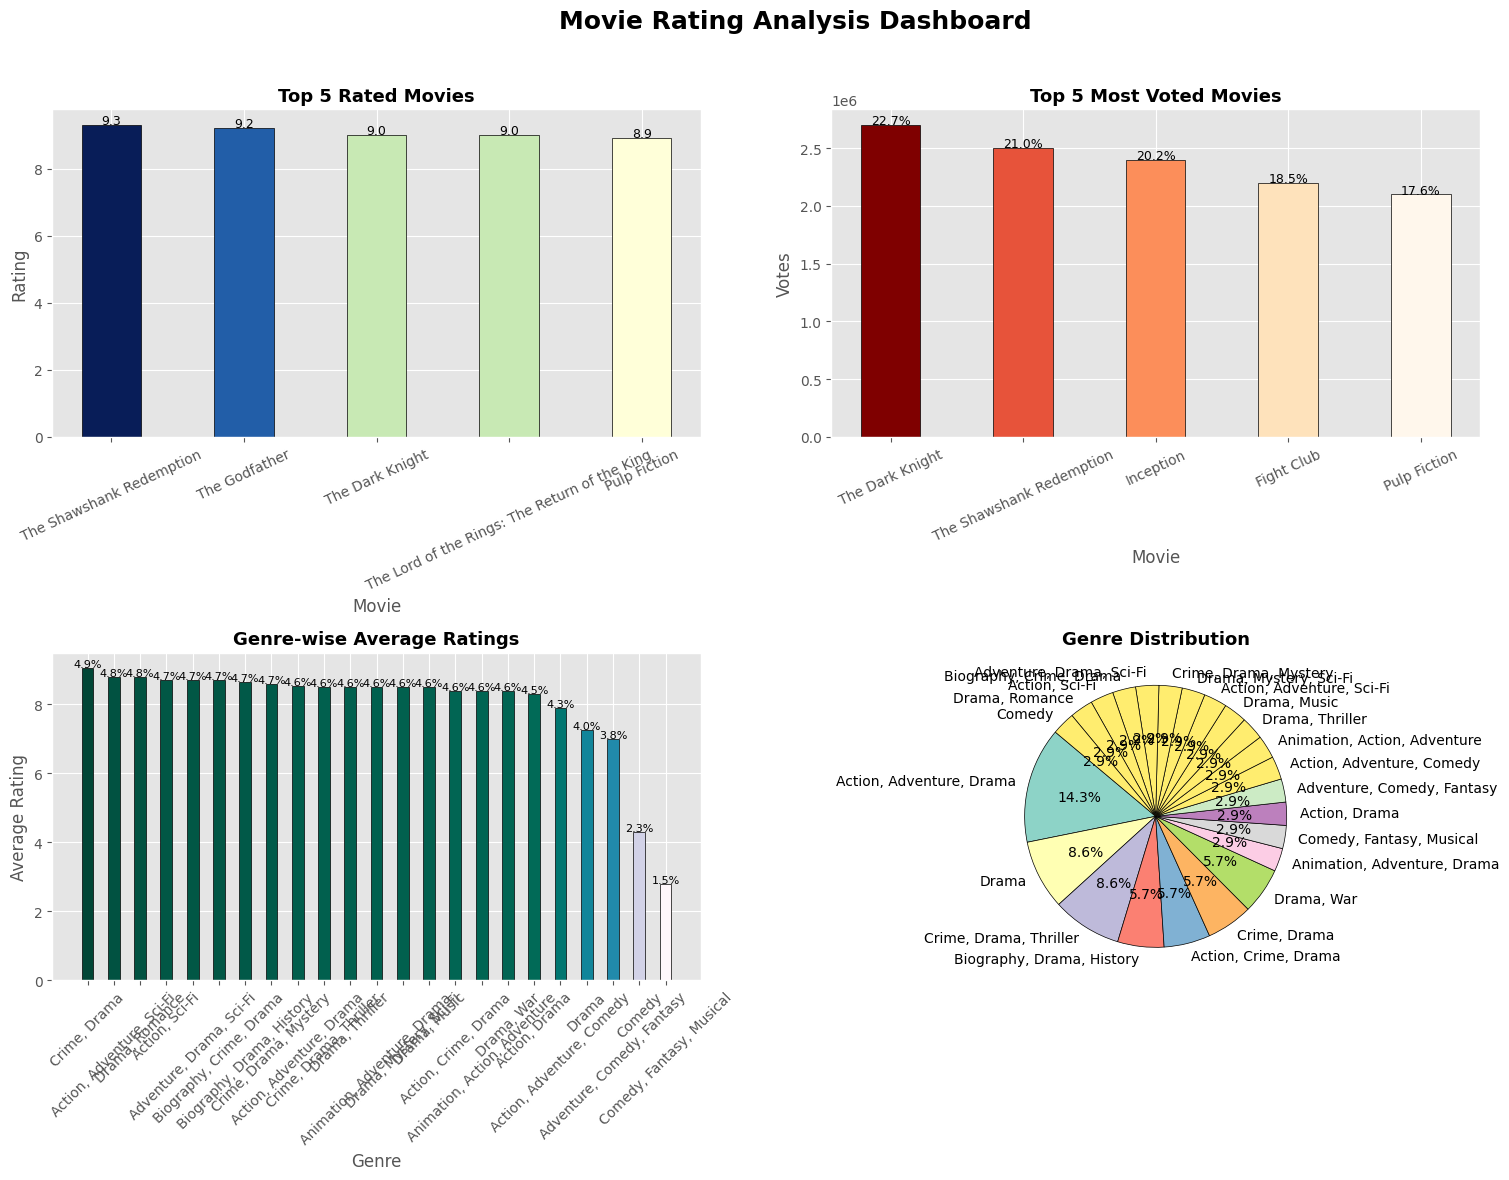


Analysis completed successfully!


In [50]:
# Color helper
def get_colors(values, cmap_name="viridis"):
    norm = Normalize(vmin=min(values), vmax=max(values))
    cmap = cm.get_cmap(cmap_name)
    return [cmap(norm(v)) for v in values]

# Visualization
plt.style.use("ggplot")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Movie Rating Analysis Dashboard", fontsize=18, fontweight="bold")

# Top 5 Rated Movies
colors1 = get_colors(top_rated["Rating"], "YlGnBu")
axes[0, 0].bar(top_rated["Movie_Name"], top_rated["Rating"], color=colors1, width=0.45, edgecolor="black")
axes[0, 0].set_title("Top 5 Rated Movies", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Movie")
axes[0, 0].set_ylabel("Rating")
axes[0, 0].tick_params(axis="x", rotation=25)
for i, v in enumerate(top_rated["Rating"]):
    axes[0, 0].text(i, v + 0.03, f"{v:.1f}", ha="center", fontsize=9)

# Top 5 Most Voted Movies
vote_percent = (top_voted["Votes"] / top_voted["Votes"].sum()) * 100
colors2 = get_colors(vote_percent, "OrRd")
axes[0, 1].bar(top_voted["Movie_Name"], top_voted["Votes"], color=colors2, width=0.45, edgecolor="black")
axes[0, 1].set_title("Top 5 Most Voted Movies", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Movie")
axes[0, 1].set_ylabel("Votes")
axes[0, 1].tick_params(axis="x", rotation=25)
for i, (v, p) in enumerate(zip(top_voted["Votes"], vote_percent)):
    axes[0, 1].text(i, v + 5000, f"{p:.1f}%", ha="center", fontsize=9)

# Genre-wise Average Ratings
genre_percent = (genre_avg / genre_avg.sum()) * 100
colors3 = get_colors(genre_percent, "PuBuGn")
axes[1, 0].bar(genre_avg.index, genre_avg.values, color=colors3, width=0.45, edgecolor="black")
axes[1, 0].set_title("Genre-wise Average Ratings", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Genre")
axes[1, 0].set_ylabel("Average Rating")
axes[1, 0].tick_params(axis="x", rotation=45)
for i, (v, p) in enumerate(zip(genre_avg.values, genre_percent)):
    axes[1, 0].text(i, v + 0.03, f"{p:.1f}%", ha="center", fontsize=8)

# Genre Distribution Pie Chart
pie_colors = cm.Set3(range(len(genre_count)))
axes[1, 1].pie(
    genre_count.values,
    labels=genre_count.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops={"edgecolor": "black"}
)
axes[1, 1].set_title("Genre Distribution", fontsize=13, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nAnalysis completed successfully!")